# FireGrounder V3 — FPN-lite Heatmap Training

Notebook huấn luyện mô hình V3 kết hợp:

**Từ V3 pipeline:**
- FPN-lite fusion stride-4 + stride-8 → heatmap 64×64 → soft-argmax
- Focal Loss (α=0.5, γ=2.0) cho classification head
- Weighted MSE heatmap + SmoothL1 coordinate loss
- Coord-safe augmentation: HFlip cập nhật `x_norm = 1 - x_norm`
- Early stopping (patience=7)

**Từ Week 6 methodology:**
- 3-way split: test gốc tách riêng, chỉ train được chia train/val
- Smoke test forward + backward trước khi train thật
- Log PCK@10px, PCK@25px, MAE, P90
- Learning curve visualization 3 subplot
- `split_info` lưu vào checkpoint

Checkpoint lưu vào `v3_outputs/` (local) hoặc `/kaggle/working/` (Kaggle).
Không ghi đè checkpoint V2.

In [1]:
# Cell 1: Install dependencies (Kaggle only)
import subprocess, sys
try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm', 'matplotlib'])
    import timm
print(f'timm {timm.__version__}')

timm 1.0.29


In [4]:
# Cell 2: Imports, Config, Device
import json, os, random, math, time, glob
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

os.environ['FIRE_IMAGE_ROOT'] = r'd:\2D Detection\FireGrounder-V3-main'


# ─── Reproducibility ────────────────────────────────────────────────
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
seed_everything()

# ─── Project paths ──────────────────────────────────────────────────
PROJECT_DIR = Path.cwd()
# Thêm project dir vào sys.path để import firegrounder_v3
import sys
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from firegrounder_v3 import (
    FireGrounderV3, FireLossV3, FocalLoss, SoftArgmax2D,
    make_gaussian_target, load_checkpoint_v3,
    BACKBONE_NAME, IMG_SIZE, HEATMAP_SIZE, MEAN, STD, FIRE_THRESHOLD,
)

# ─── Hyperparameters ─────────────────────────────────────────────────
EPOCHS          = 50
BATCH_SIZE      = 48
LR              = 1.5e-4
WEIGHT_DECAY    = 3e-4
PATIENCE        = 7
VAL_RATIO       = 0.15
TEST_RATIO      = 0.10   # Giữ 10% test riêng nếu không detect được test/ từ path
W_CLS           = 1.5
W_HEATMAP       = 5.0
W_COORD         = 1.0
GAUSSIAN_SIGMA  = 2.0
THRESHOLD       = FIRE_THRESHOLD
NUM_WORKERS     = 0

# ─── Override by env vars (for scripted runs) ───────────────────────
JSON_PATH    = os.environ.get('FIRE_JSON_PATH', '')
IMAGE_ROOT   = os.environ.get('FIRE_IMAGE_ROOT', '')
OUTPUT_DIR   = os.environ.get('FIRE_OUTPUT_DIR', '')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🚀 Device: {DEVICE}')
print(f'📐 IMG_SIZE={IMG_SIZE}  HEATMAP={HEATMAP_SIZE}  BATCH={BATCH_SIZE}')
print(f'📊 EPOCHS={EPOCHS}  LR={LR}  PATIENCE={PATIENCE}')

🚀 Device: cuda
📐 IMG_SIZE=256  HEATMAP=64  BATCH=48
📊 EPOCHS=50  LR=0.00015  PATIENCE=7


## 1. Load dataset và 3-way split (train / val / test)

- Nếu `image_path` chứa `/test/` → gán vào **test set** (giữ kín).
- Phần còn lại chia thành **train / val** theo `VAL_RATIO`.
- Nếu không detect được cấu trúc `/test/` → random split 3 phần.
- Các bản ghi trùng tên file được loại trước khi chia.

In [5]:
# Cell 3: Tìm dataset JSON + image index

def find_json_file() -> Path:
    """Auto-discover dataset_labels.json, ưu tiên fire_ground_dataset/."""
    if JSON_PATH:
        p = Path(JSON_PATH)
        assert p.exists(), f'JSON not found: {p}'
        return p
    candidates = []
    for root in [Path('/kaggle/input'), PROJECT_DIR, Path.cwd()]:
        if root.exists():
            candidates.extend(root.glob('**/dataset_labels.json'))
            candidates.extend(root.glob('**/dataset_labels*.json'))
    candidates = list({p.resolve() for p in candidates if p.exists()})
    # Ưu tiên file trong fire_ground_dataset (6500 records)
    candidates.sort(key=lambda p: ('fire_ground_dataset' not in str(p), len(str(p))))
    assert candidates, '❌ Không tìm thấy dataset_labels.json!'
    return candidates[0]


def build_image_index() -> Dict[str, Path]:
    """Index toàn bộ ảnh để resolve path nhanh."""
    roots = [Path('/kaggle/input'), PROJECT_DIR]
    if IMAGE_ROOT:
        roots.insert(0, Path(IMAGE_ROOT))
    index = {}
    exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob('*'):
            if p.is_file() and p.suffix.lower() in exts:
                index.setdefault(p.name.lower(), p)
                index.setdefault(p.as_posix().lower(), p)
    print(f'📂 Image index: {len(index)} entries')
    return index


def resolve_image(raw_path: str, index: Dict[str, Path]) -> Path:
    direct = Path(raw_path)
    if direct.exists():
        return direct
    norm = raw_path.replace('\\', '/').lower()
    if norm in index:
        return index[norm]
    basename = Path(norm).name
    if basename in index:
        return index[basename]
    raise FileNotFoundError(f'Image not found: {raw_path}')


json_file = find_json_file()
with open(json_file, encoding='utf-8') as f:
    all_records = json.load(f)

n_fire = sum(1 for r in all_records if r.get('has_fire', 1) == 1)
print(f'📄 Dataset: {json_file}')
print(f'📊 Total: {len(all_records)} | 🔥 Fire: {n_fire} | 🌿 No-fire: {len(all_records)-n_fire}')

image_index = build_image_index()

📄 Dataset: D:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\fire_ground_dataset\dataset_labels.json
📊 Total: 6500 | 🔥 Fire: 4509 | 🌿 No-fire: 1991
📂 Image index: 13000 entries


In [8]:
# Cell 4: 3-way split — giữ test gốc tách riêng

def split_records_3way(records, seed=SEED, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO):
    """Split records into train/val/test.
    
    Strategy:
    - Nếu image_path chứa '/test/' → test set (giữ kín)
    - Phần còn lại → shuffle → chia val + train
    - Nếu không detect được /test/ → random 3-way split
    """
    # Dedup by filename
    seen = set()
    unique = []
    for r in records:
        name = Path(r['image_path']).name.lower()
        if name not in seen:
            seen.add(name)
            unique.append(r)
    if len(unique) < len(records):
        print(f'  ⚠️ Loại {len(records) - len(unique)} bản ghi trùng filename')
    records = unique
    
    # Detect test from path structure
    test_records = [r for r in records if '/test/' in r.get('image_path', '')]
    non_test = [r for r in records if '/test/' not in r.get('image_path', '')]
    
    if len(test_records) >= 10:
        # Có test gốc → dùng nó
        print(f'  ✅ Detect test từ path structure: {len(test_records)} test records')
        trainval = non_test
    else:
        # Không detect được → random split
        print(f'  ℹ️ Không detect /test/ trong paths → random 3-way split')
        rng = random.Random(seed)
        shuffled = records.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(len(shuffled) * test_ratio))
        test_records = shuffled[:n_test]
        trainval = shuffled[n_test:]
    
    # Split trainval → train + val
    rng = random.Random(seed)
    rng.shuffle(trainval)
    n_val = max(1, int(len(trainval) * val_ratio))
    val_records = trainval[:n_val]
    train_records = trainval[n_val:]
    
    return {'train': train_records, 'val': val_records, 'test': test_records}


splits = split_records_3way(all_records)
split_info = {}
for name, items in splits.items():
    n_f = sum(1 for r in items if r.get('has_fire', 1) == 1)
    split_info[name] = {'count': len(items), 'fire': n_f, 'no_fire': len(items) - n_f}
    print(f'  [{name:5s}] {len(items):5d} samples  (🔥 {n_f}, 🌿 {len(items)-n_f})')

assert all(split_info[k]['count'] > 0 for k in ('train', 'val', 'test')), \
    'One or more splits are empty!'

  ✅ Detect test từ path structure: 1300 test records
  [train]  4420 samples  (🔥 3128, 🌿 1292)
  [val  ]   780 samples  (🔥 529, 🌿 251)
  [test ]  1300 samples  (🔥 852, 🌿 448)


In [9]:
# Cell 5: Dataset class + DataLoaders

class FireDatasetV3(Dataset):
    """Dataset with coordinate-safe augmentation.
    
    Augmentation (train only):
    - ColorJitter (brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08)
    - Coord-safe HFlip: x_new = 1.0 - x_old
    - Random Gamma (0.7 - 1.4)
    - RandomErasing (p=0.25)
    """
    def __init__(self, records: list, index: dict, train: bool = True):
        self.records = records
        self.index = index
        self.train = train
        self.jitter = transforms.ColorJitter(0.4, 0.4, 0.3, 0.08)
        self.erase = transforms.RandomErasing(0.25, (0.02, 0.15), (0.3, 3.3), 'random')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item = self.records[idx]
        img = Image.open(resolve_image(str(item['image_path']), self.index)).convert('RGB')
        has_fire = float(item.get('has_fire', 1))
        
        if has_fire > 0.5:
            x, y = item.get('p_fire', [0.0, 0.0])[:2]
            x = max(0.0, min(1.0, float(x)))
            y = max(0.0, min(1.0, float(y)))
        else:
            x, y = 0.0, 0.0

        if self.train:
            img = self.jitter(img)
            if random.random() < 0.5:
                img = TF.hflip(img)
                if has_fire > 0.5:
                    x = 1.0 - x  # ⚠️ CRITICAL: coord-safe flip
            if random.random() < 0.3:
                img = TF.adjust_gamma(img, random.uniform(0.7, 1.4))

        img = TF.resize(img, [IMG_SIZE, IMG_SIZE])
        tensor = TF.to_tensor(img)
        if self.train:
            tensor = self.erase(tensor)
        tensor = TF.normalize(tensor, MEAN, STD)
        
        target = torch.tensor([has_fire, x, y], dtype=torch.float32)
        return tensor, target


# Create datasets
train_ds = FireDatasetV3(splits['train'], image_index, train=True)
val_ds   = FireDatasetV3(splits['val'],   image_index, train=False)
test_ds  = FireDatasetV3(splits['test'],  image_index, train=False)

# Create loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check
images, targets = next(iter(train_loader))
print(f'\n✅ Batch check: images={tuple(images.shape)}, targets={tuple(targets.shape)}')
print(f'   First target [has_fire, x_norm, y_norm]: {targets[0].tolist()}')


✅ Batch check: images=(48, 3, 256, 256), targets=(48, 3)
   First target [has_fire, x_norm, y_norm]: [1.0, 0.5359370112419128, 0.7444440126419067]


## 2. Smoke test — kiểm tra forward + backward trước khi train

Cell này **phải chạy thành công** trước khi bắt đầu train dài.
Dùng `pretrained=False` để nhanh, chỉ kiểm tra shape và loss finite.

In [10]:
# Cell 6: Smoke test
smoke_model = FireGrounderV3(pretrained=False).to(DEVICE)
smoke_criterion = FireLossV3(w_cls=W_CLS, w_heatmap=W_HEATMAP, w_coord=W_COORD,
                             gaussian_sigma=GAUSSIAN_SIGMA)

smoke_images = images[:2].to(DEVICE)
smoke_targets = targets[:2].to(DEVICE)

# Forward
smoke_outputs = smoke_model(smoke_images, return_dict=True)

# Loss + backward
smoke_loss, smoke_parts = smoke_criterion(smoke_outputs, smoke_targets)
smoke_loss.backward()

# Assertions
assert smoke_outputs['pred'].shape == (2, 3), f'pred shape: {smoke_outputs["pred"].shape}'
assert smoke_outputs['heatmap_logits'].shape == (2, 1, HEATMAP_SIZE, HEATMAP_SIZE)
assert torch.isfinite(smoke_loss), f'Loss is not finite: {smoke_loss.item()}'
xy_pred = smoke_outputs['pred'][:, 1:]
assert (xy_pred >= 0).all() and (xy_pred <= 1).all(), 'xy out of [0,1]'

print({k: f'{v.item():.6f}' for k, v in smoke_parts.items()})
print({k: tuple(v.shape) for k, v in smoke_outputs.items() if hasattr(v, 'shape')})
print('\n✅ Smoke test PASSED — model, loss và backward đều OK')
del smoke_model, smoke_criterion, smoke_outputs, smoke_loss

[FireGrounderV3] backbone=mobilenetv4_conv_medium channels=[48, 80, 960] heatmap=64 params=7,545,650
{'cls': '0.087919', 'heatmap': '0.285955', 'coord': '0.065434', 'total': '1.627086'}
{'pred': (2, 3), 'p_fire': (2,), 'xy': (2, 2), 'heatmap_logits': (2, 1, 64, 64)}

✅ Smoke test PASSED — model, loss và backward đều OK


## 3. Khởi tạo model và optimizer

Dùng `pretrained=True` khi train thật. Architecture:

```
MobileNetV4-Medium (features_only)
    ├── f4  (stride-4, 64×64) ──┐
    ├── f8  (stride-8, 32×32) ──┤ FPN-lite fusion → heatmap 64×64
    └── f32 (stride-32, 8×8) ── cls_head → p_fire
```

In [11]:
# Cell 7: Model, loss, optimizer, scheduler
model = FireGrounderV3(pretrained=True).to(DEVICE)
criterion = FireLossV3(w_cls=W_CLS, w_heatmap=W_HEATMAP, w_coord=W_COORD,
                       gaussian_sigma=GAUSSIAN_SIGMA)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR / 100
)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable: {trainable:,}')

Unexpected keys (norm_head.num_batches_tracked, classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


[FireGrounderV3] backbone=mobilenetv4_conv_medium channels=[48, 80, 960] heatmap=64 params=7,545,650
Total parameters: 7,545,650
Trainable: 7,545,650


## 4. Training loop

- Best model chọn theo **val total loss**.
- Metrics tọa độ (MAE, PCK) log riêng, không ảnh hưởng checkpoint selection.
- Early stopping patience = 7.
- Gradient clipping max_norm = 1.0.

In [12]:
# Cell 8: Metrics, epoch runners, training loop

# ─── Metrics ─────────────────────────────────────────────────────────
@torch.no_grad()
def compute_metrics(preds: torch.Tensor, targets: torch.Tensor) -> Dict[str, float]:
    """Classification + localization metrics."""
    pred_fire = preds[:, 0] >= THRESHOLD
    true_fire = targets[:, 0] > 0.5
    
    tp = int((pred_fire & true_fire).sum())
    tn = int((~pred_fire & ~true_fire).sum())
    fp = int((pred_fire & ~true_fire).sum())
    fn = int((~pred_fire & true_fire).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    
    if true_fire.any():
        errors = torch.linalg.vector_norm(
            (preds[true_fire, 1:3] - targets[true_fire, 1:3]) * IMG_SIZE, dim=1
        )
        mae_px   = float(errors.mean())
        median   = float(errors.median())
        p90      = float(torch.quantile(errors, 0.9))
        pck10    = float((errors <= 10).float().mean())  # PCK@10px
        pck25    = float((errors <= 25).float().mean())  # PCK@25px
        within5  = float((errors <= 5).float().mean() * 100)
    else:
        mae_px = median = p90 = float('nan')
        pck10 = pck25 = within5 = float('nan')
    
    return {
        'precision': precision, 'recall': recall, 'f1': f1,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'mae_px': mae_px, 'median_px': median, 'p90_px': p90,
        'pck10': pck10, 'pck25': pck25, 'within5_pct': within5,
    }


# ─── Epoch runners ───────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, count = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images, return_dict=True)
        loss, parts = criterion(outputs, labels)
        if not torch.isfinite(loss):
            raise FloatingPointError(f'Non-finite loss at step')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(images)
        count += len(images)
    return total_loss / max(count, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, count = 0.0, 0
    all_preds, all_targets = [], []
    loss_parts_sum = {}
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images, return_dict=True)
        loss, parts = criterion(outputs, labels)
        total_loss += loss.item() * len(images)
        count += len(images)
        all_preds.append(outputs['pred'].cpu())
        all_targets.append(labels.cpu())
        for k, v in parts.items():
            loss_parts_sum[k] = loss_parts_sum.get(k, 0.0) + v.item() * len(images)
    
    avg_loss = total_loss / max(count, 1)
    avg_parts = {k: v / max(count, 1) for k, v in loss_parts_sum.items()}
    metrics = compute_metrics(torch.cat(all_preds), torch.cat(all_targets))
    return avg_loss, avg_parts, metrics


# ─── Checkpoint saver ─────────────────────────────────────────────
def save_checkpoint(path, model, optimizer, scheduler, epoch, val_loss, metrics):
    torch.save({
        'model_version': FireGrounderV3.model_version,
        'model_state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'backbone': BACKBONE_NAME,
        'img_size': IMG_SIZE,
        'heatmap_size': HEATMAP_SIZE,
        'hidden_channels': model.hidden_channels,
        'softargmax_temperature': model.softargmax_temperature,
        'epoch': epoch,
        'val_loss': val_loss,
        'metrics': metrics,
        'split_info': split_info,
        'config': {
            'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'lr': LR,
            'weight_decay': WEIGHT_DECAY, 'patience': PATIENCE,
            'w_cls': W_CLS, 'w_heatmap': W_HEATMAP, 'w_coord': W_COORD,
            'gaussian_sigma': GAUSSIAN_SIGMA, 'threshold': THRESHOLD,
        },
    }, path)


# ─── Output directory ────────────────────────────────────────────────
if OUTPUT_DIR:
    out_dir = Path(OUTPUT_DIR)
elif Path('/kaggle/working').exists():
    out_dir = Path('/kaggle/working')
else:
    out_dir = PROJECT_DIR / 'v3_outputs'
out_dir.mkdir(parents=True, exist_ok=True)

best_path = out_dir / 'best_v3_fpn.pth'
last_path = out_dir / 'last_v3_fpn.pth'


# ─── Main training loop ──────────────────────────────────────────────
best_val = float('inf')
wait = 0
history = []

print(f'\n{"Epoch":>5} {"Train":>10} {"Val":>10} {"P":>6} {"R":>6} '
      f'{"F1":>6} {"FP":>4} {"FN":>4} {"MAE":>7} {"PCK10":>6} {"PCK25":>6}')
print('─' * 85)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_parts, val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()
    
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_parts': val_parts,
        'val_metric': val_metrics,
    }
    history.append(row)
    
    improved = val_loss < best_val
    mark = ' ★' if improved else ''
    
    m = val_metrics
    mae_s = f"{m['mae_px']:.1f}" if not math.isnan(m['mae_px']) else '  -'
    pck10_s = f"{m['pck10']:.3f}" if not math.isnan(m['pck10']) else '  -'
    pck25_s = f"{m['pck25']:.3f}" if not math.isnan(m['pck25']) else '  -'
    
    print(f"{epoch:5d} {train_loss:10.5f} {val_loss:10.5f} "
          f"{m['precision']:6.3f} {m['recall']:6.3f} {m['f1']:6.3f} "
          f"{m['fp']:4.0f} {m['fn']:4.0f} {mae_s:>7}px {pck10_s:>6} {pck25_s:>6}{mark}")
    
    if improved:
        best_val = val_loss
        wait = 0
        save_checkpoint(best_path, model, optimizer, scheduler, epoch, val_loss, val_metrics)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'\n⏹ Early stopping at epoch {epoch} (patience={PATIENCE})')
            break
    
    # Lưu last checkpoint mỗi epoch
    save_checkpoint(last_path, model, optimizer, scheduler, epoch, val_loss, val_metrics)

elapsed = time.time() - t0
print(f'\n✅ Training done in {elapsed/60:.1f} min')
print(f'   Best val loss: {best_val:.6f}')
print(f'   Best checkpoint: {best_path}')

# Save history
(out_dir / 'train_history_v3.json').write_text(
    json.dumps(history, indent=2, allow_nan=True, default=str), encoding='utf-8'
)


Epoch      Train        Val      P      R     F1   FP   FN     MAE  PCK10  PCK25
─────────────────────────────────────────────────────────────────────────────────────
    1    0.82907    0.39064  0.948  0.968  0.958   28   17    40.3px  0.176  0.425 ★
    2    0.38836    0.20355  0.926  0.994  0.959   42    3    32.1px  0.331  0.569 ★
    3    0.24678    0.14541  0.961  0.987  0.974   21    7    30.7px  0.374  0.601 ★
    4    0.12742    0.10568  0.968  0.987  0.978   17    7    25.7px  0.454  0.664 ★
    5    0.09225    0.08573  0.961  0.985  0.973   21    8    25.9px  0.527  0.699 ★
    6    0.07399    0.07648  0.961  0.987  0.974   21    7    23.2px  0.554  0.735 ★
    7    0.06167    0.06466  0.972  0.981  0.976   15   10    21.2px  0.584  0.758 ★
    8    0.05515    0.06114  0.961  0.991  0.976   21    5    22.4px  0.592  0.758 ★
    9    0.04966    0.05523  0.977  0.983  0.980   12    9    20.3px  0.628  0.779 ★
   10    0.04518    0.05552  0.972  0.985  0.978   15    8    20.9p

17941

## 5. Đánh giá trên test set độc lập

**KHÔNG** dùng test loss để chọn checkpoint.
Cell này chỉ chạy sau khi train xong, dùng test gốc tách riêng.

In [13]:
# Cell 9: Test evaluation
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_parts, test_metrics = evaluate(model, test_loader, criterion, DEVICE)

print('\n' + '═'*60)
print('  TEST SET EVALUATION (held-out, never seen during training)')
print('═'*60)
print(f'  Loss:      {test_loss:.6f}')
print(f'  Loss parts: {test_parts}')
print(f'  Precision: {test_metrics["precision"]:.4f}')
print(f'  Recall:    {test_metrics["recall"]:.4f}')
print(f'  F1:        {test_metrics["f1"]:.4f}')
print(f'  FP={test_metrics["fp"]:.0f}  FN={test_metrics["fn"]:.0f}')
print(f'  MAE:       {test_metrics["mae_px"]:.2f} px')
print(f'  Median:    {test_metrics["median_px"]:.2f} px')
print(f'  P90:       {test_metrics["p90_px"]:.2f} px')
print(f'  PCK@10px:  {test_metrics["pck10"]:.3f}')
print(f'  PCK@25px:  {test_metrics["pck25"]:.3f}')
print(f'  ≤5px:      {test_metrics["within5_pct"]:.1f}%')
print('═'*60)

# Save test metrics
test_report = {
    'checkpoint': str(best_path),
    'dataset': str(json_file),
    'resolution': IMG_SIZE,
    'threshold': THRESHOLD,
    'split_info': split_info,
    'test_loss': test_loss,
    'test_parts': test_parts,
    'test_metrics': test_metrics,
    'best_epoch': ckpt.get('epoch', '?'),
}
(out_dir / 'test_metrics_v3.json').write_text(
    json.dumps(test_report, indent=2, allow_nan=True, default=str), encoding='utf-8'
)
print(f'\n📝 Test metrics saved: {out_dir / "test_metrics_v3.json"}')


════════════════════════════════════════════════════════════
  TEST SET EVALUATION (held-out, never seen during training)
════════════════════════════════════════════════════════════
  Loss:      0.158024
  Loss parts: {'cls': 0.08800306612482438, 'heatmap': 0.0037640480116869395, 'coord': 0.007199271954596043, 'total': 0.15802411081699225}
  Precision: 0.9750
  Recall:    0.8685
  F1:        0.9187
  FP=19  FN=112
  MAE:       23.96 px
  Median:    4.94 px
  P90:       89.57 px
  PCK@10px:  0.655
  PCK@25px:  0.757
  ≤5px:      50.2%
════════════════════════════════════════════════════════════

📝 Test metrics saved: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\test_metrics_v3.json


## 6. Learning curves

3 subplot:
1. **Total loss** (train vs val) — đánh giá overfitting
2. **MAE pixel** — đánh giá localization quality
3. **PCK@10 và PCK@25** — đánh giá tỷ lệ dự đoán đúng

⚠️ Nếu val loss giảm nhưng MAE/PCK không cải thiện → cần điều chỉnh nhãn hoặc loss tọa độ.

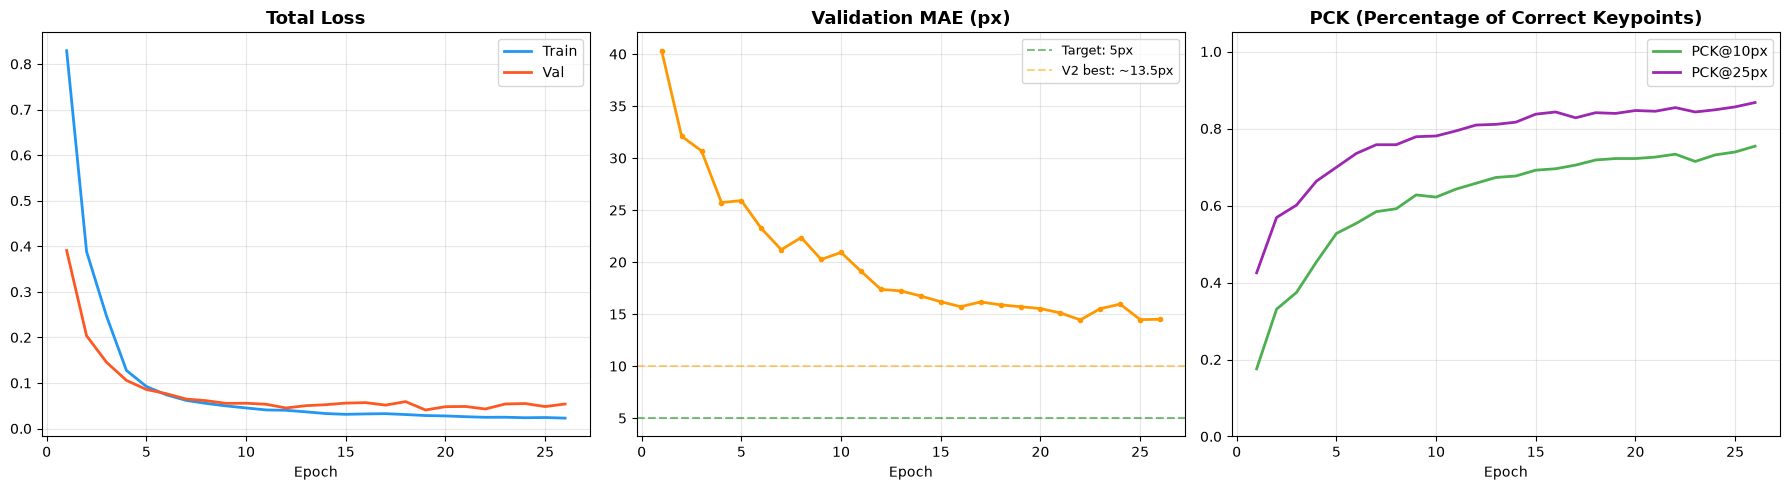

📈 Saved: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\learning_curve_v3.png


In [14]:
# Cell 10: Learning curves
epochs_list = [r['epoch'] for r in history]
train_losses = [r['train_loss'] for r in history]
val_losses = [r['val_loss'] for r in history]
val_mae = [r['val_metric']['mae_px'] for r in history]
val_pck10 = [r['val_metric']['pck10'] for r in history]
val_pck25 = [r['val_metric']['pck25'] for r in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_list, train_losses, label='Train', color='#2196F3', linewidth=2)
axes[0].plot(epochs_list, val_losses, label='Val', color='#FF5722', linewidth=2)
axes[0].set_title('Total Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(epochs_list, val_mae, color='#FF9800', linewidth=2, marker='o', markersize=3)
axes[1].axhline(y=5.0, color='green', linestyle='--', alpha=0.5, label='Target: 5px')
axes[1].axhline(y=10.0, color='orange', linestyle='--', alpha=0.5, label='V2 best: ~13.5px')
axes[1].set_title('Validation MAE (px)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# PCK
axes[2].plot(epochs_list, val_pck10, label='PCK@10px', color='#4CAF50', linewidth=2)
axes[2].plot(epochs_list, val_pck25, label='PCK@25px', color='#9C27B0', linewidth=2)
axes[2].set_ylim(0, 1.05)
axes[2].set_title('PCK (Percentage of Correct Keypoints)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / 'learning_curve_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📈 Saved: {out_dir / "learning_curve_v3.png"}')

## 7. Visual preview — GT vs Prediction

Vẽ 12 ảnh validation ngẫu nhiên:
- 🟢 **Lime dot** = Ground Truth (SAM3 label)
- 🔴 **Red cross** = V3 prediction
- Title = `p_fire` confidence

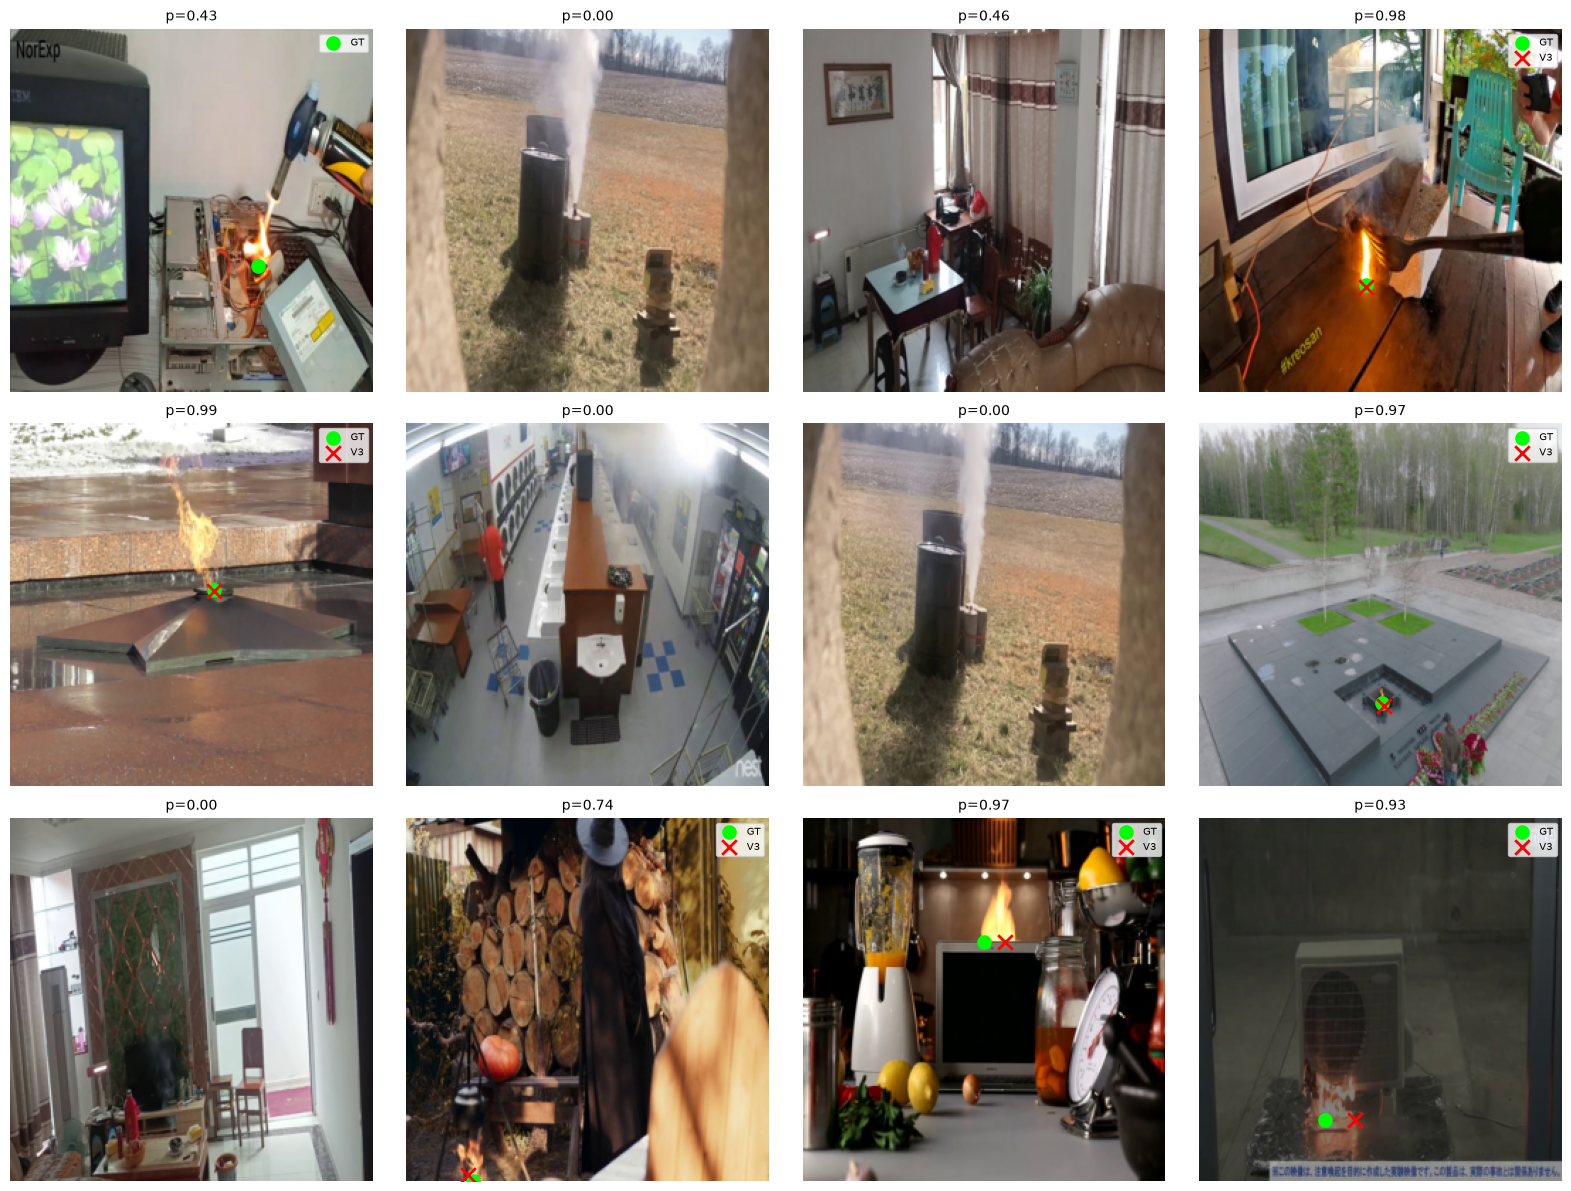

📸 Saved: d:\2D Detection\FireGrounder-V3-main\FireGrounder-V3-main\v3_outputs\v3_val_preview.png


In [15]:
# Cell 11: Visual preview
n_show = min(12, len(val_ds))
show_idx = random.Random(999).sample(range(len(val_ds)), n_show)
cols = 4
rows = max(1, (n_show + cols - 1) // cols)

inverse_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1.0/s for s in STD]
)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = np.asarray(axes).reshape(-1)

model.eval()
for ax, idx in zip(axes, show_idx):
    tensor, target = val_ds[idx]
    with torch.no_grad():
        pred = model(tensor.unsqueeze(0).to(DEVICE))[0].cpu().numpy()
    
    img_show = inverse_norm(tensor).permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img_show)
    
    if target[0] > 0.5:
        ax.scatter(target[1]*IMG_SIZE, target[2]*IMG_SIZE,
                   c='lime', s=90, zorder=5, label='GT')
    if pred[0] >= THRESHOLD:
        ax.scatter(pred[1]*IMG_SIZE, pred[2]*IMG_SIZE,
                   c='red', marker='x', s=110, linewidths=2, zorder=5, label='V3')
    ax.set_title(f'p={pred[0]:.2f}', fontsize=10)
    ax.axis('off')
    if target[0] > 0.5 or pred[0] >= THRESHOLD:
        ax.legend(fontsize=7, loc='upper right')

for ax in axes[n_show:]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(out_dir / 'v3_val_preview.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'📸 Saved: {out_dir / "v3_val_preview.png"}')

## Lưu ý khi tích hợp

### Checkpoint compatibility
- `best_v3_fpn.pth` **không tương thích** với `inference.py` (V1/V2).
- Dùng `inference_v3.py` hoặc `load_checkpoint_v3()` từ `firegrounder_v3.py`.

### So sánh với V2
- V2 baseline: F1=98.4%, MAE=13.5px, Latency=12ms.
- V3 phải được so sánh **cùng seed, cùng val split, cùng threshold**.
- Báo cáo cả PCK@10, P90, và test set metrics.

### Pipeline 3D
- `(x_norm, y_norm)` từ V3 có thể nối trực tiếp vào `CameraGeometry.pixel_to_ray()`.
- Cần viết adapter nếu pipeline hiện tại dùng `fire_detector.py` cũ.

### Không dùng test set để chọn checkpoint
- File `ground_truth.json` (10 ảnh thủ công) dành cho đánh giá localization riêng.
- Không dùng nó trong notebook này.